LOAD MODELS & FEATURE FILES

In [1]:
import joblib
rainfall_model = joblib.load(
    "../models/xgboost_rainfall_model.pkl"
)
heatwave_model = joblib.load(
    "../models/xgboost_heatwave_model.pkl"
)
rainfall_features = joblib.load(
    "../models/rainfall_feature_names.pkl"
)
heatwave_features = joblib.load(
    "../models/heatwave_feature_names.pkl"
)
print("Rainfall Features:", len(rainfall_features))
print("Heatwave Features:", len(heatwave_features))
print(
    "\nRainfall Model Features:",
    rainfall_model.n_features_in_
)
print(
    "Heatwave Model Features:",
    heatwave_model.n_features_in_
)


Rainfall Features: 94
Heatwave Features: 93

Rainfall Model Features: 94
Heatwave Model Features: 93


LOAD DATASET FOR SHAP

In [2]:
import pandas as pd

df = pd.read_csv("../datasets/processed/climate_anomalies.csv")
print("Dataset Loaded Successfully")
print("Shape:", df.shape)
print("\nRainfall Features Missing:", len(set(rainfall_features) - set(df.columns)))
print("Heatwave Features Missing:", len(set(heatwave_features) - set(df.columns)))
X_rainfall = df[rainfall_features]
X_heatwave = df[heatwave_features]
print("\nRainfall SHAP Shape:")
print(X_rainfall.shape)
print("\nHeatwave SHAP Shape:")
print(X_heatwave.shape)

Dataset Loaded Successfully
Shape: (119398, 149)

Rainfall Features Missing: 0
Heatwave Features Missing: 0

Rainfall SHAP Shape:
(119398, 94)

Heatwave SHAP Shape:
(119398, 93)


CREATE SHAP EXPLAINERS

In [3]:
import shap

rainfall_explainer = shap.TreeExplainer(rainfall_model)
heatwave_explainer = shap.TreeExplainer(heatwave_model)
print("Rainfall SHAP Explainer Created")
print("Heatwave SHAP Explainer Created")

c:\Projects\ClimateGuardAI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Rainfall SHAP Explainer Created
Heatwave SHAP Explainer Created


CREATE SHAP VALUES SAMPLE

In [4]:
sample_size = 1000
X_rainfall_sample = X_rainfall.sample(sample_size, random_state=42)
X_heatwave_sample = X_heatwave.sample(sample_size, random_state=42)
rainfall_shap_values = rainfall_explainer.shap_values(X_rainfall_sample)
heatwave_shap_values = heatwave_explainer.shap_values(X_heatwave_sample)
print("Rainfall SHAP Generated")
print("Heatwave SHAP Generated")
print("\nRainfall Shape:")
print(rainfall_shap_values.shape)
print("\nHeatwave Shape:")
print(heatwave_shap_values.shape)

Rainfall SHAP Generated
Heatwave SHAP Generated

Rainfall Shape:
(1000, 94, 3)

Heatwave Shape:
(1000, 93, 3)


RAINFALL GLOBAL SHAP

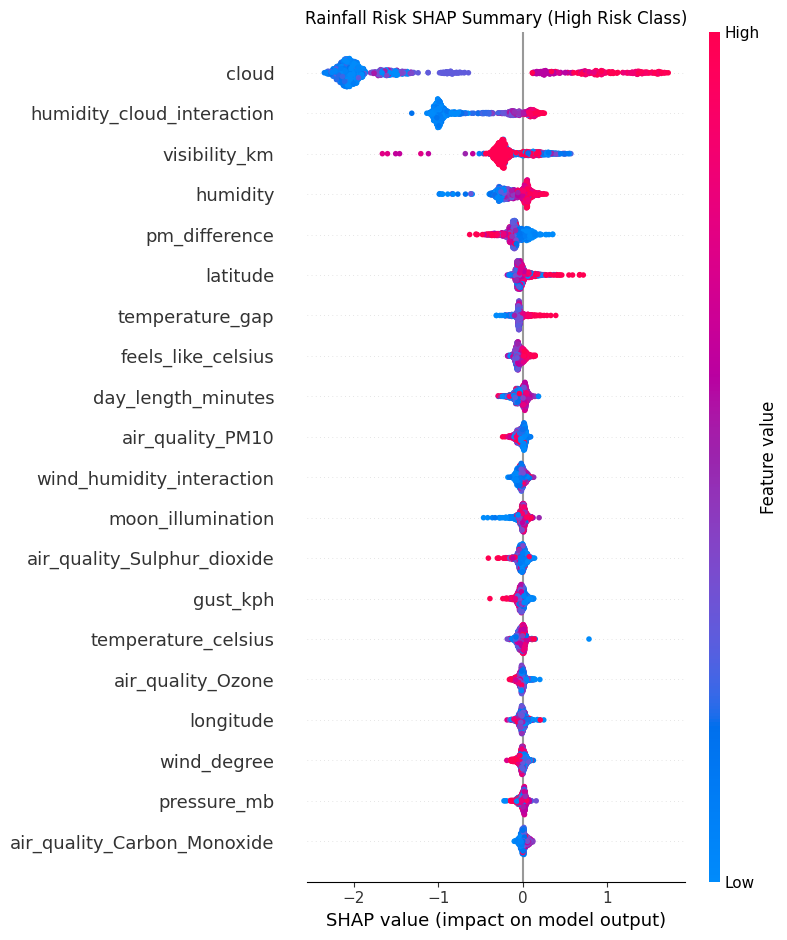

In [5]:
import shap
import matplotlib.pyplot as plt

shap.summary_plot(rainfall_shap_values[:, :, 2], X_rainfall_sample, show=False)
plt.title("Rainfall Risk SHAP Summary (High Risk Class)")
plt.tight_layout()
plt.show()

In [6]:
import numpy as np
importance = np.abs(
    rainfall_shap_values[:, :, 2]
).mean(axis=0)
top_features = (
    pd.DataFrame({
        "Feature": X_rainfall_sample.columns,
        "Importance": importance
    })
    .sort_values(
        "Importance",
        ascending=False
    )
)
print(top_features.head(20))


                        Feature  Importance
7                         cloud    1.667386
31   humidity_cloud_interaction    0.687398
9                 visibility_km    0.237529
6                      humidity    0.147987
28                pm_difference    0.109134
0                      latitude    0.061492
27              temperature_gap    0.056090
8            feels_like_celsius    0.050985
26           day_length_minutes    0.050233
17             air_quality_PM10    0.036850
30    wind_humidity_interaction    0.036829
20            moon_illumination    0.035894
15  air_quality_Sulphur_dioxide    0.035789
11                     gust_kph    0.035179
2           temperature_celsius    0.032902
13            air_quality_Ozone    0.030038
1                     longitude    0.029437
4                   wind_degree    0.029261
5                   pressure_mb    0.028659
12  air_quality_Carbon_Monoxide    0.027938


HEATWAVE GLOBAL SHAP

In [7]:
importance = abs(heatwave_shap_values[:, :, 0]).mean(axis=0)
top_features = pd.DataFrame(
    {"Feature": X_heatwave_sample.columns, "Importance": importance}
).sort_values("Importance", ascending=False)
print(top_features.head(20))

                         Feature  Importance
2            temperature_celsius    3.702305
31                heatwave_index    0.910806
7                       humidity    0.782046
0                       latitude    0.198778
5                    pressure_mb    0.126257
29     wind_humidity_interaction    0.114358
1                      longitude    0.104550
26            day_length_minutes    0.095487
13             air_quality_Ozone    0.082577
30    humidity_cloud_interaction    0.072573
9                  visibility_km    0.068537
27                 pm_difference    0.058678
22                         month    0.052705
14  air_quality_Nitrogen_dioxide    0.041312
20             moon_illumination    0.041270
17              air_quality_PM10    0.037182
11                      gust_kph    0.033952
15   air_quality_Sulphur_dioxide    0.033784
4                    wind_degree    0.029438
48                     region_17    0.026264


SINGLE PREDICTION EXPLANATION

In [8]:
sample_index = 0
rainfall_prediction = rainfall_model.predict(X_rainfall_sample.iloc[[sample_index]])
print("Predicted Rainfall Class:", rainfall_prediction[0])
shap_values_single = rainfall_explainer.shap_values(
    X_rainfall_sample.iloc[[sample_index]]
)
print("SHAP Shape:", shap_values_single.shape)

Predicted Rainfall Class: 1
SHAP Shape: (1, 94, 3)


TOP CONTRIBUTORS FOR THIS PREDICTION

In [9]:
import pandas as pd
import numpy as np

class_index = rainfall_prediction[0]
local_importance = pd.DataFrame(
    {
        "Feature": X_rainfall_sample.columns,
        "SHAP_Value": shap_values_single[0, :, class_index],
    }
)
local_importance["Absolute_SHAP"] = local_importance["SHAP_Value"].abs()
local_importance = local_importance.sort_values("Absolute_SHAP", ascending=False)
print(local_importance[["Feature", "SHAP_Value"]].head(15))

                        Feature  SHAP_Value
7                         cloud    2.316639
31   humidity_cloud_interaction    1.190286
9                 visibility_km    0.410752
28                pm_difference    0.117602
27              temperature_gap    0.106321
0                      latitude    0.078302
12  air_quality_Carbon_Monoxide   -0.071716
6                      humidity    0.043016
26           day_length_minutes    0.034144
20            moon_illumination   -0.032139
29          pollution_intensity   -0.031987
1                     longitude    0.030670
8            feels_like_celsius    0.028234
13            air_quality_Ozone   -0.025749
22                        month   -0.020897
